# 3. Рекуррентные нейросети

Необходимо реализовать следующие архитектуры рекуррентных сетей:
- RNN (персептрон с обратной связью);
- GRU;
- LSTM.

Сравнить результаты обучения данных моделей при прогнозировании энергопотребления (выбран данный датасет).

## Использованные библиотеки

Будем использовать интерфейс Kedas, встроенный в библиотеку Tensorflow, со встроенными оп

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf

from keras.models import Sequential
from keras.layers import SimpleRNN, GRU, LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from numpy.random import randn


print("Библиотеки успешно импортированы!")

Библиотеки успешно импортированы!


### Препроцессинг

In [2]:
file_name = 'household_power_consumption.txt'
df = pd.read_csv(file_name,
                 delimiter=';',
                 na_values=['?'],
                 parse_dates={'datetime': ['Date', 'Time']},
                 low_memory=False)

df.set_index('datetime', inplace=True)

print(df.info())
print(df.describe(include="all"))
print("Number of missing values:")
print(df.isnull().sum())

/tmp/ipykernel_1476/1793111546.py:2: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(file_name,
/tmp/ipykernel_1476/1793111546.py:2: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(file_name,


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None
       Global_active_power  Global_reactive_power       Voltage  \
count         2.049280e+06           2.049280e+06  2.049280e+06   
mean          1.091615e+00           1.237145e-01  2.408399e+02   
std           1.057294e+00           1.127220e-01  3.239987e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.080000e-01           4.800000e-02  2.389900e+02   
50%           6.020000e-01           1.000000e-01  2.410100e+02   
75%           1

In [3]:
# Проверка, идут ли пропуски подряд
missing_summary = df.isna().sum(axis=1)
partial_missing = missing_summary[missing_summary.between(1, 6)]

print(f"Строк с частичными пропусками: {len(partial_missing)}")

Строк с частичными пропусками: 0


Нет строк с частичными пропусками (то есть, где не пропущено хотя бы одно значение, не считая даты и времени).
В таком случае, при работе с отсутствующими значениями достаточно анализировать один столбец.

Используем столбец Global_active_power для выявления пустых строк.

In [4]:
# Маска пустых строк
missing_mask = df['Global_active_power'].isna()

# Нумерация непрерывных серий строк с присутствующими/пропущенными значениями
series_id = (missing_mask != missing_mask.shift()).cumsum()

# Оставляет только те, где пропуски
missing_series = series_id[missing_mask]

series_lengths = missing_series.value_counts().sort_index()

print("Длины серий пропусков (в минутах):")
print(series_lengths.value_counts().sort_index())

print(f"\nВсего серий: {len(series_lengths)}")
print(f"Максимальная длина: {series_lengths.max()} минут")
print(f"Медианная длина: {series_lengths.median()} минут")

Длины серий пропусков (в минутах):
count
1       38
2       14
3        2
4        1
6        1
21       1
24       1
33       1
38       1
43       1
47       1
70       1
83       1
891      1
2027     1
3129     1
3305     1
3723     1
5237     1
7226     1
Name: count, dtype: int64

Всего серий: 71
Максимальная длина: 7226 минут
Медианная длина: 1.0 минут


In [5]:
# Поскольку у нас пропущенные значения полностью покрывают строку (или
# не покрывает вовсе), то можем построить маску на основе одного из столбцов
mask = ~df['Global_active_power'].isna()

df_clean = df[mask].copy()
df_clean['weekday'] = df_clean.index.weekday
df_clean['hour_minute'] = df_clean.index.strftime('%H:%M')

templates = {}
for col in df.columns:
  # Строим копию без строк с пропусками
  templates[col] = df_clean.groupby(['weekday', 'hour_minute'])[col].median()


# Пропущенные даты
missing_mask = df['Global_active_power'].isna()
missed_dates = df.index[missing_mask]

if missing_mask.any():
  weekdays = df.index[missing_mask].weekday
  hour_minutes = df.index[missing_mask].strftime('%H:%M')
  multi_idx = pd.MultiIndex.from_arrays([weekdays, hour_minutes], names=['weekday', 'hour_minute'])

  for col in df.columns:
    df.loc[missing_mask, col] = templates[col].loc[multi_idx].values

  print(f"Заполнено {missing_mask.sum()} пропусков в {len(df.columns)} столбцах")
else:
  print("Пропусков нет")

Заполнено 25979 пропусков в 7 столбцах


Проверка:

In [6]:
print(df.info())
print(df.describe(include="all"))
print("Number of missing values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float64
 1   Global_reactive_power  float64
 2   Voltage                float64
 3   Global_intensity       float64
 4   Sub_metering_1         float64
 5   Sub_metering_2         float64
 6   Sub_metering_3         float64
dtypes: float64(7)
memory usage: 126.7 MB
None
       Global_active_power  Global_reactive_power       Voltage  \
count         2.075259e+06           2.075259e+06  2.075259e+06   
mean          1.089616e+00           1.235271e-01  2.408410e+02   
std           1.052528e+00           1.120641e-01  3.223446e+00   
min           7.600000e-02           0.000000e+00  2.232000e+02   
25%           3.100000e-01           4.800000e-02  2.390100e+02   
50%           6.060000e-01           1.000000e-01  2.410100e+02   
75%           1

# Создание нейросети

Будем тренироваться предсказывать значения на основе 'Global_active_power'.

Перел обучением проведем агрегацию до часов (для ускорения обучения модели).

In [7]:
print(f"Сейчас: {len(df)} строк")  # ~2,075,259

# Агрегация до часов
df_hourly = df.resample('h').mean()
print(f"После агрегации: {len(df_hourly)} строк")

Сейчас: 2075259 строк
После агрегации: 34589 строк


In [8]:
tf.random.set_seed(42)
np.random.seed(42)

# Создаем последовательности для обучения
def create_sequences(data, seq_length=168):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])  # предсказываем следующий час
    return np.array(X), np.array(y)

# Возьмем один столбец для предсказаний
target_col = 'Global_active_power'
data = df_hourly[target_col].values.reshape(-1, 1)

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Создаем последовательности
seq_length = 24 * 7  # 7 дней по часам (168 шагов)
X, y = create_sequences(data_scaled, seq_length)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (24094, 168, 1), Val: (5163, 168, 1), Test: (5164, 168, 1)


In [9]:
print("GPU доступен:", tf.config.list_physical_devices('GPU'))
print("Имя GPU:", tf.test.gpu_device_name())

GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Имя GPU: /device:GPU:0


* Простой RNN (Elman network):

In [ ]:
def create_rnn_model(seq_length, n_features=1):
    model = Sequential([
        SimpleRNN(64, activation='tanh', input_shape=(seq_length, n_features),
                  return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

rnn_model = create_rnn_model(seq_length)
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,337 (24.75 KB)

 Trainable params: 6,337 (24.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

rnn_history = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 17s 15ms/step - loss: 0.0109 - mae: 0.0741 - val_loss: 0.0089 - val_mae: 0.0676
Epoch 2/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0094 - mae: 0.0682 - val_loss: 0.0087 - val_mae: 0.0662
Epoch 3/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0094 - mae: 0.0678 - val_loss: 0.0088 - val_mae: 0.0651
Epoch 4/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0093 - mae: 0.0673 - val_loss: 0.0087 - val_mae: 0.0648
Epoch 5/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0094 - mae: 0.0678 - val_loss: 0.0089 - val_mae: 0.0673
Epoch 6/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0093 - mae: 0.0677 - val_loss: 0.0089 - val_mae: 0.0661
Epoch 7/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 0.0093 - mae: 0.0674 - val_loss: 0.0092 - val_mae: 0.0683
Epoch 8/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 0.0092 - mae: 0.0674 - val_loss: 0.0086 - val_mae: 0.0642
Epoch 9/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 11m

* GRU - Gated Recurrent Unit

In [ ]:
def create_gru_model(seq_length, n_features=1):
    model = Sequential([
        GRU(64, activation='tanh', input_shape=(seq_length, n_features),
            return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.1),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

gru_model = create_gru_model(seq_length)
gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,977 (58.50 KB)

 Trainable params: 14,977 (58.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 0.0110 - mae: 0.0740 - val_loss: 0.0096 - val_mae: 0.0674
Epoch 2/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0100 - mae: 0.0699 - val_loss: 0.0093 - val_mae: 0.0666
Epoch 3/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.0096 - mae: 0.0686 - val_loss: 0.0089 - val_mae: 0.0642
Epoch 4/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 0.0093 - mae: 0.0675 - val_loss: 0.0086 - val_mae: 0.0638
Epoch 5/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0092 - mae: 0.0669 - val_loss: 0.0087 - val_mae: 0.0652
Epoch 6/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 0.0091 - mae: 0.0664 - val_loss: 0.0085 - val_mae: 0.0639
Epoch 7/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.0090 - mae: 0.0661 - val_loss: 0.0085 - val_mae: 0.0637
Epoch 8/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0090 - mae: 0.0659 - val_loss: 0.0085 - val_mae: 0.0648
Epoch 9/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 9s 11

* LSTM - Long short-term memory

In [ ]:
def create_lstm_model(seq_length, n_features=1):
    model = Sequential([
        LSTM(128, activation='tanh', input_shape=(seq_length, n_features),
             return_sequences=True),
        Dropout(0.2),
        LSTM(64, activation='tanh', return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

lstm_model = create_lstm_model(seq_length)
lstm_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 168, 128)       │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 168, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 118,081 (461.25 KB)

 Trainable params: 118,081 (461.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=1
)

Epoch 1/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 0.0124 - mae: 0.0808 - val_loss: 0.0092 - val_mae: 0.0678
Epoch 2/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0095 - mae: 0.0679 - val_loss: 0.0086 - val_mae: 0.0643
Epoch 3/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0092 - mae: 0.0665 - val_loss: 0.0086 - val_mae: 0.0647
Epoch 4/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0090 - mae: 0.0657 - val_loss: 0.0086 - val_mae: 0.0660
Epoch 5/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - loss: 0.0089 - mae: 0.0651 - val_loss: 0.0083 - val_mae: 0.0647
Epoch 6/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0088 - mae: 0.0646 - val_loss: 0.0082 - val_mae: 0.0644
Epoch 7/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - loss: 0.0087 - mae: 0.0643 - val_loss: 0.0082 - val_mae: 0.0635
Epoch 8/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - loss: 0.0087 - mae: 0.0639 - val_loss: 0.0084 - val_mae: 0.0645
Epoch 9/50
753/753 ━━━━━━━━━━━━━━━━━━━━ 

# Графики и сравнение моделей


RNN Model Results:
162/162 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step


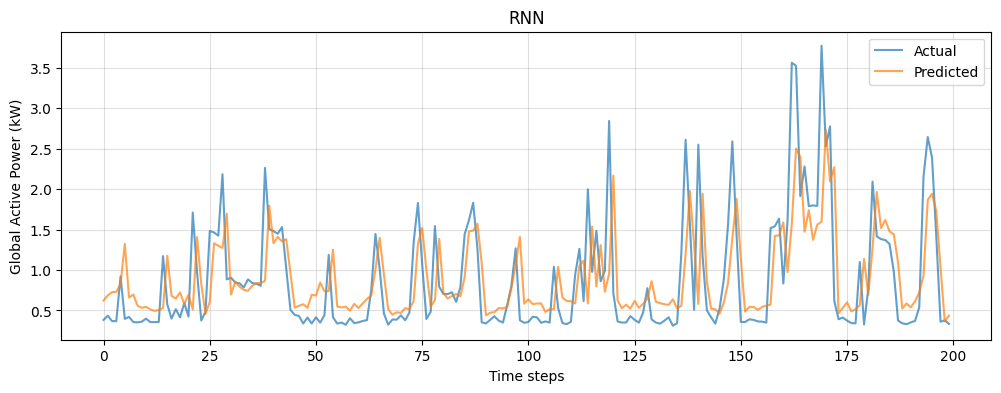


RNN - MAE: 0.352 kW, RMSE: 0.490 kW

GRU Model Results:
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


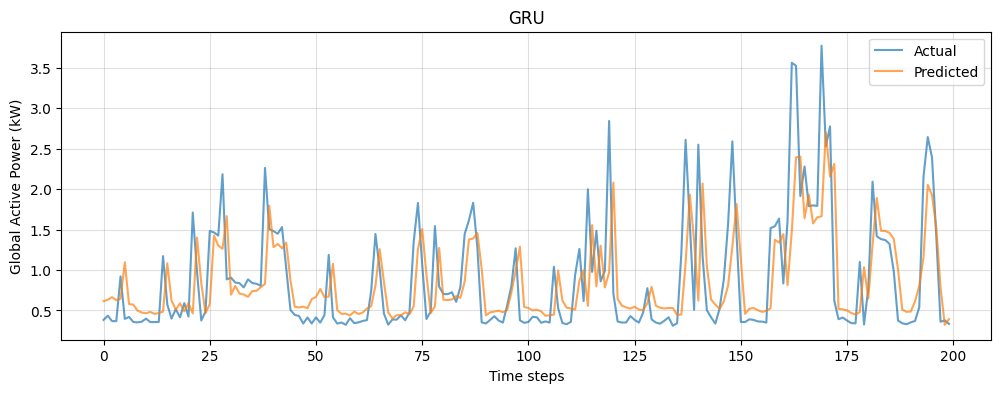


GRU - MAE: 0.329 kW, RMSE: 0.475 kW

LSTM Model Results:
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


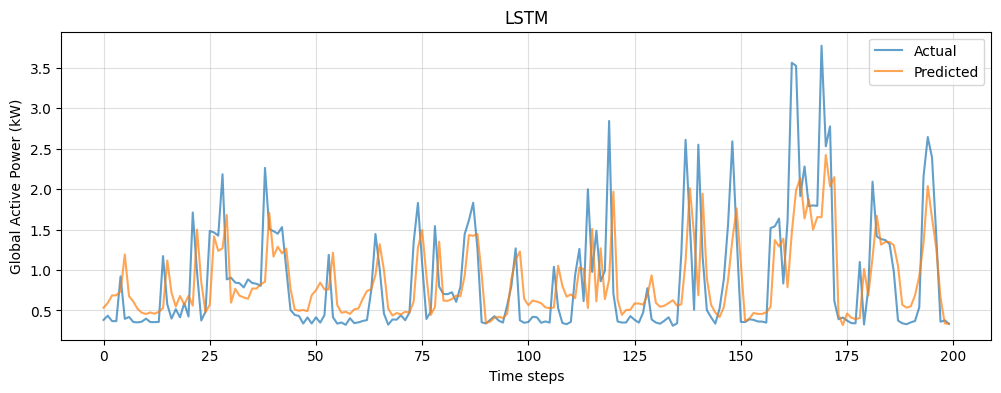


LSTM - MAE: 0.330 kW, RMSE: 0.473 kW

Сравнение моделей:
           MAE      RMSE
RNN   0.351980  0.490224
GRU   0.329426  0.474971
LSTM  0.329843  0.472707


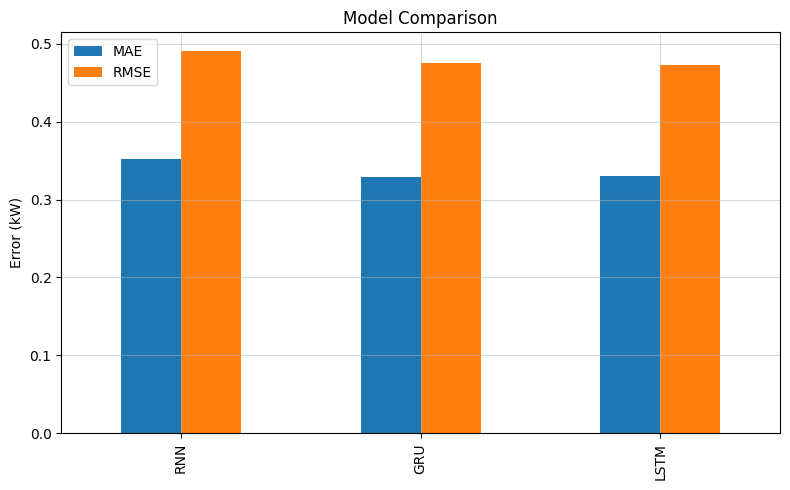

In [ ]:
import matplotlib.pyplot as plt

def plot_predictions(model, X_test, y_test, scaler, title):
    predictions = model.predict(X_test)                 # Предсказание
    predictions = scaler.inverse_transform(predictions) # К исходному масштабу
    actual = scaler.inverse_transform(y_test.reshape(-1, 1))

    plt.figure(figsize=(12, 4))
    plt.plot(actual[:200], label='Actual', alpha=0.7)
    plt.plot(predictions[:200], label='Predicted', alpha=0.7)
    plt.title(title)
    plt.xlabel('Time steps')
    plt.ylabel('Global Active Power (kW)')
    plt.legend()
    plt.grid(True, alpha=0.4)
    plt.show()

    # Метрики
    mae = np.mean(np.abs(predictions - actual))
    rmse = np.sqrt(np.mean((predictions - actual)**2))
    print(f"\n{title} - MAE: {mae:.3f} kW, RMSE: {rmse:.3f} kW")
    return mae, rmse

# Сравниваем все три
print("="*50)
results = {}
for name, model in [('RNN', rnn_model), ('GRU', gru_model), ('LSTM', lstm_model)]:
    print(f"\n{name} Model Results:")
    mae, rmse = plot_predictions(model, X_test, y_test, scaler, name)
    results[name] = {'MAE': mae, 'RMSE': rmse}

# Визуализация сравнения
results_df = pd.DataFrame(results).T
print("\n" + "="*50)
print("Сравнение моделей:")
print(results_df)

results_df.plot(kind='bar', figsize=(8, 5))
plt.title('Model Comparison')
plt.ylabel('Error (kW)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# Самостоятельная реализация

In [15]:
class RNN:
  def __init__(self, input_size, output_size, hidden_size=64, learning_rate=0.001):
    # Веса - матрицы
    self.W_xh = randn(hidden_size, input_size) * np.sqrt(1 / input_size)
    self.W_hh = randn(hidden_size, hidden_size) * np.sqrt(1 / hidden_size)
    self.W_hy = randn(output_size, hidden_size) * np.sqrt(1 / hidden_size)

    # Смещения - нулевые векторы
    self.b_h = np.zeros((hidden_size, 1))
    self.b_y = np.zeros((output_size, 1))

    self.hidden_size = hidden_size
    self.learning_rate = learning_rate

  def forward(self, x):
    '''
    Вход: x = (seq_len, input_size)
    Выход: y = (seq_len, output_size)
    '''
    seq_len = x.shape[0]

    # Инициализация h
    h = np.zeros((self.hidden_size, 1))

    # Промежуточные состояния
    h_states = [h]
    y_outputs = []

    # Прохождение по временным шагам
    for t in range(seq_len):
      x_t = x[t].reshape(-1, 1) # транспонируем вектор для умножения на матрицу
      h_t = np.tanh((self.W_xh @ x_t) + (self.W_hh @ h) + self.b_h)
      y_t = self.W_hy @ h_t + self.b_y

      h_states.append(h_t)
      y_outputs.append(y_t)
      h = h_t
    # Кэшируем вход и промежуточные состояния
    cache = (x, y_outputs, h_states)
    #return np.array(y_outputs).reshape(-1, 1), cache
    return np.stack(y_outputs).squeeze(-1), cache

  def backward(self, dy, cache):
    """
    dy: градиент ошибки по выходу (seq_len, output_size)
    cache: (x, y_outputs, h_states)
    """
    x, y_outputs, h_states = cache
    seq_len = len(y_outputs)

    # Инициализация градиентов
    dW_xh = np.zeros_like(self.W_xh)
    dW_hh = np.zeros_like(self.W_hh)
    dW_hy = np.zeros_like(self.W_hy)
    db_h = np.zeros_like(self.b_h)
    db_y = np.zeros_like(self.b_y)

    # Градиент по скрытому состоянию (передается назад во времени)
    dh_next = np.zeros((self.hidden_size, 1))

    for t in reversed(range(seq_len)):
        # Градиент по выходному слою
        dy_t = dy[t].reshape(-1, 1)

        dW_hy += dy_t @ h_states[t+1].T
        db_y += dy_t

        # Градиент по скрытому состоянию от выхода
        dh = self.W_hy.T @ dy_t + dh_next

        # tanh производная: dtanh = dh * (1 - tanh^2)
        h_t = h_states[t+1]
        dtanh = dh * (1 - h_t**2)

        # Градиенты по весам на шаге t
        x_t = x[t].reshape(-1, 1)
        dW_xh += (dtanh @ x_t.T)
        dW_hh += (dtanh @ h_states[t].T)
        db_h += dtanh

        # Градиент для следующего шага (обратно во времени)
        dh_next = (self.W_hh.T @ dtanh)

    grads = {
        'dW_xh': dW_xh,
        'dW_hh': dW_hh,
        'dW_hy': dW_hy,
        'db_h': db_h,
        'db_y': db_y
    }

    return grads

  def update_parameters(self, grads):
    self.W_xh -= self.learning_rate * grads['dW_xh']
    self.W_hh -= self.learning_rate * grads['dW_hh']
    self.W_hy -= self.learning_rate * grads['dW_hy']
    self.b_h -= self.learning_rate * grads['db_h']
    self.b_y -= self.learning_rate * grads['db_y']

  def train_step(self, x_batch, y_batch):
    """
    x_batch: (batch_size, seq_len, input_size)
    y_batch: (batch_size, seq_len, output_size)
    """
    param_to_grad = {
      'W_xh': 'dW_xh',
      'W_hh': 'dW_hh',
      'W_hy': 'dW_hy',
      'b_h': 'db_h',
      'b_y': 'db_y'
    }
    total_loss = 0
    batch_grads = {
      grad_name: np.zeros_like(getattr(self, param_name))
      for param_name, grad_name in param_to_grad.items()
    }

    for i in range(len(x_batch)):
        # Forward pass
        y_pred, cache = self.forward(x_batch[i])

        # Loss
        loss = self.compute_loss(y_pred, y_batch[i])
        total_loss += loss

        # Градиент по выходу (dy = 2*(y_pred - y_true) для MSE)
        #dy = 2 * (y_pred - y_batch[i]) / len(y_pred)
        dy = 2 * (y_pred - y_batch[i]) / y_pred.size

        # Backward pass
        grads = self.backward(dy, cache)

        # Суммируем градиенты по батчу
        for param_name, grad_name in param_to_grad.items():
          batch_grads[grad_name] += grads[grad_name]

    # Усредняем градиенты по батчу
    for key in batch_grads:
        batch_grads[key] /= len(x_batch)

    # Обновляем параметры
    self.update_parameters(batch_grads)

    return total_loss / len(x_batch)

  def predict(self, x):
    """
    x: (seq_len, input_size) или (batch_size, seq_len, input_size)
    """
    single_sequence = len(x.shape) == 2

    if single_sequence:
        y_pred, _ = self.forward(x)
        return y_pred
    else:
        predictions = []
        for i in range(x.shape[0]):
            y_pred, _ = self.forward(x[i])
            predictions.append(y_pred)
        return np.stack(predictions, axis=0)

  def compute_loss(self, y_pred, y_true):
    """
    MSE (Mean Squared Error)
    """
    return np.mean((y_pred - y_true) ** 2)

  def compute_mae(self, y_pred, y_true):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_pred - y_true))

  def compute_rmse(self, y_pred, y_true):
    """Root Mean Squared Error"""
    return np.sqrt(self.compute_loss(y_pred, y_true))

  def compute_mape(self, y_pred, y_true):
    """Mean Absolute Percentage Error"""
    mask = y_true != 0
    y_pred_flat = y_pred.reshape(-1)
    y_true_flat = y_true.reshape(-1)
    mask_flat = mask.reshape(-1)
    return np.mean(np.abs((y_true_flat[mask_flat] - y_pred_flat[mask_flat]) /
                           y_true_flat[mask_flat])) * 100

  def fit(self, X_train, y_train, epochs = 50, batch_size = 32):
    for epoch in range(epochs):
      # Перемешивание батчей
      indices = np.random.permutation(len(X_train))
      epoch_loss = 0
      num_batches = 0

      for i in range(0, len(X_train), batch_size):
          batch_indices = indices[i:i+batch_size]
          x_batch = X_train[batch_indices]
          #y_batch = y_train[batch_indices].reshape(-1, 1, 1)
          y_batch = y_train[batch_indices]

          loss = self.train_step(x_batch, y_batch)
          epoch_loss += loss
          num_batches += 1

      print(f"Epoch {epoch}, Loss: {(epoch_loss / num_batches):.6f}")



In [25]:
import numpy as np

class FastRNN:
    def __init__(self, input_size, output_size, hidden_size=64, learning_rate=0.001):
        self.hidden_size = hidden_size
        self.lr = learning_rate

        # Xavier init
        self.W_xh = np.random.randn(input_size, hidden_size) * np.sqrt(1/input_size)
        self.W_hh = np.random.randn(hidden_size, hidden_size) * np.sqrt(1/hidden_size)
        self.W_hy = np.random.randn(hidden_size, output_size) * np.sqrt(1/hidden_size)

        self.b_h = np.zeros((1, hidden_size))
        self.b_y = np.zeros((1, output_size))

    def forward(self, x):
        """
        x: (B, T, input_size)
        """

        B, T, _ = x.shape

        h = np.zeros((B, self.hidden_size))

        h_states = []
        y_outputs = []

        for t in range(T):
            x_t = x[:, t, :]                      # (B, input)

            h = np.tanh(
                x_t @ self.W_xh +
                h @ self.W_hh +
                self.b_h
            )                                     # (B, hidden)

            y = h @ self.W_hy + self.b_y          # (B, output)

            h_states.append(h.copy())
            y_outputs.append(y)

        h_states = np.stack(h_states, axis=1)      # (B,T,H)
        y_outputs = np.stack(y_outputs, axis=1)    # (B,T,O)

        cache = (x, h_states)

        return y_outputs, cache

    def backward(self, dy, cache):
        """
        dy: (B,T,O)
        """

        x, h_states = cache
        B, T, _ = x.shape

        dW_xh = np.zeros_like(self.W_xh)
        dW_hh = np.zeros_like(self.W_hh)
        dW_hy = np.zeros_like(self.W_hy)

        db_h = np.zeros_like(self.b_h)
        db_y = np.zeros_like(self.b_y)

        dh_next = np.zeros((B, self.hidden_size))

        for t in reversed(range(T)):

            h_t = h_states[:, t, :]
            h_prev = h_states[:, t-1, :] if t > 0 else np.zeros_like(h_t)

            x_t = x[:, t, :]
            dy_t = dy[:, t, :]

            # output layer
            dW_hy += h_t.T @ dy_t
            db_y += np.sum(dy_t, axis=0, keepdims=True)

            dh = dy_t @ self.W_hy.T + dh_next

            dtanh = dh * (1 - h_t**2)

            dW_xh += x_t.T @ dtanh
            dW_hh += h_prev.T @ dtanh
            db_h += np.sum(dtanh, axis=0, keepdims=True)

            dh_next = dtanh @ self.W_hh.T

        # усреднение по batch
        for g in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            g /= B

        # gradient clipping
        for g in [dW_xh, dW_hh, dW_hy, db_h, db_y]:
            np.clip(g, -5, 5, out=g)

        return {
            'dW_xh': dW_xh,
            'dW_hh': dW_hh,
            'dW_hy': dW_hy,
            'db_h': db_h,
            'db_y': db_y
        }

    def update_parameters(self, grads):
        self.W_xh -= self.lr * grads['dW_xh']
        self.W_hh -= self.lr * grads['dW_hh']
        self.W_hy -= self.lr * grads['dW_hy']
        self.b_h -= self.lr * grads['db_h']
        self.b_y -= self.lr * grads['db_y']

    def train_step(self, x_batch, y_batch):
      y_pred, cache = self.forward(x_batch)

      # берём только последний timestep
      y_pred_last = y_pred[:, -1, :]   # (B, output)

      loss = np.mean((y_pred_last - y_batch) ** 2)

      dy = np.zeros_like(y_pred)
      dy[:, -1, :] = 2 * (y_pred_last - y_batch) / y_batch.size

      grads = self.backward(dy, cache)

      self.update_parameters(grads)

      return loss

    def predict(self, x):
        if x.ndim == 2:
            x = x[np.newaxis, :, :]
            y, _ = self.forward(x)
            return y[0]
        else:
            y, _ = self.forward(x)
            return y

    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        N = len(X_train)

        for epoch in range(epochs):
            indices = np.random.permutation(N)
            total_loss = 0
            num_batches = 0

            for i in range(0, N, batch_size):
                batch_idx = indices[i:i+batch_size]

                x_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]

                loss = self.train_step(x_batch, y_batch)

                total_loss += loss
                num_batches += 1

            print(f"Epoch {epoch}, Loss: {total_loss/num_batches:.6f}")

In [38]:
rnn = FastRNN(input_size=1, hidden_size=64, output_size=1)
print('Модель RNN создана.')

rnn.fit(X_train, y_train, epochs=50, batch_size=32)

Модель RNN создана.
Epoch 0, Loss: 0.159540
Epoch 1, Loss: 0.111710
Epoch 2, Loss: 0.092646
Epoch 3, Loss: 0.082633
Epoch 4, Loss: 0.075607
Epoch 5, Loss: 0.069826
Epoch 6, Loss: 0.064793
Epoch 7, Loss: 0.060313
Epoch 8, Loss: 0.056292
Epoch 9, Loss: 0.052678
Epoch 10, Loss: 0.049417
Epoch 11, Loss: 0.046469
Epoch 12, Loss: 0.043798
Epoch 13, Loss: 0.041376
Epoch 14, Loss: 0.039171
Epoch 15, Loss: 0.037162
Epoch 16, Loss: 0.035332
Epoch 17, Loss: 0.033658
Epoch 18, Loss: 0.032126
Epoch 19, Loss: 0.030724
Epoch 20, Loss: 0.029438
Epoch 21, Loss: 0.028253
Epoch 22, Loss: 0.027163
Epoch 23, Loss: 0.026160
Epoch 24, Loss: 0.025233
Epoch 25, Loss: 0.024376
Epoch 26, Loss: 0.023583
Epoch 27, Loss: 0.022849
Epoch 28, Loss: 0.022168
Epoch 29, Loss: 0.021534
Epoch 30, Loss: 0.020944
Epoch 31, Loss: 0.020397
Epoch 32, Loss: 0.019885
Epoch 33, Loss: 0.019408
Epoch 34, Loss: 0.018962
Epoch 35, Loss: 0.018543
Epoch 36, Loss: 0.018152
Epoch 37, Loss: 0.017786
Epoch 38, Loss: 0.017443
Epoch 39, Loss:

In [39]:
# Оценка на тестовых данных
predictions_test = rnn.predict(X_test)

GRU:

In [52]:
import numpy as np

class FastGRU:
    def __init__(self, input_size, output_size, hidden_size=64, lr=0.001):
        self.hidden_size = hidden_size
        self.lr = lr

        # Xavier init
        def init(in_dim, out_dim):
            return np.random.randn(in_dim, out_dim) * np.sqrt(1 / in_dim)

        # gates
        self.W_z = init(input_size, hidden_size)
        self.U_z = init(hidden_size, hidden_size)
        self.b_z = np.zeros((1, hidden_size))

        self.W_r = init(input_size, hidden_size)
        self.U_r = init(hidden_size, hidden_size)
        self.b_r = np.zeros((1, hidden_size))

        self.W_h = init(input_size, hidden_size)
        self.U_h = init(hidden_size, hidden_size)
        self.b_h = np.zeros((1, hidden_size))

        self.W_y = init(hidden_size, output_size)
        self.b_y = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        B, T, _ = x.shape
        h = np.zeros((B, self.hidden_size))

        hs, zs, rs, h_tildes = [], [], [], []

        for t in range(T):
            x_t = x[:, t, :]

            z = self.sigmoid(x_t @ self.W_z + h @ self.U_z + self.b_z)
            r = self.sigmoid(x_t @ self.W_r + h @ self.U_r + self.b_r)

            h_tilde = np.tanh(x_t @ self.W_h + (r * h) @ self.U_h + self.b_h)

            h = (1 - z) * h + z * h_tilde

            hs.append(h.copy())
            zs.append(z)
            rs.append(r)
            h_tildes.append(h_tilde)

        hs = np.stack(hs, axis=1)

        y = hs @ self.W_y + self.b_y  # (B,T,O)

        cache = (x, hs, zs, rs, h_tildes)
        return y, cache

    def backward(self, dy, cache):
        x, hs, zs, rs, h_tildes = cache
        B, T, _ = x.shape

        dW_z = np.zeros_like(self.W_z)
        dU_z = np.zeros_like(self.U_z)
        db_z = np.zeros_like(self.b_z)

        dW_r = np.zeros_like(self.W_r)
        dU_r = np.zeros_like(self.U_r)
        db_r = np.zeros_like(self.b_r)

        dW_h = np.zeros_like(self.W_h)
        dU_h = np.zeros_like(self.U_h)
        db_h = np.zeros_like(self.b_h)

        dW_y = np.zeros_like(self.W_y)
        db_y = np.zeros_like(self.b_y)

        dh_next = np.zeros((B, self.hidden_size))

        for t in reversed(range(T)):
            h_t = hs[:, t, :]
            h_prev = hs[:, t-1, :] if t > 0 else np.zeros_like(h_t)

            z = zs[t]
            r = rs[t]
            h_tilde = h_tildes[t]

            x_t = x[:, t, :]
            dy_t = dy[:, t, :]

            # output
            dW_y += h_t.T @ dy_t
            db_y += np.sum(dy_t, axis=0, keepdims=True)

            dh = dy_t @ self.W_y.T + dh_next

            # h = (1-z)*h_prev + z*h_tilde
            dh_tilde = dh * z
            dz = dh * (h_tilde - h_prev)

            dh_prev = dh * (1 - z)

            # tanh
            da_h = dh_tilde * (1 - h_tilde**2)

            dW_h += x_t.T @ da_h
            dU_h += (r * h_prev).T @ da_h
            db_h += np.sum(da_h, axis=0, keepdims=True)

            dr = (da_h @ self.U_h.T) * h_prev

            # sigmoid grads
            da_r = dr * r * (1 - r)
            da_z = dz * z * (1 - z)

            dW_r += x_t.T @ da_r
            dU_r += h_prev.T @ da_r
            db_r += np.sum(da_r, axis=0, keepdims=True)

            dW_z += x_t.T @ da_z
            dU_z += h_prev.T @ da_z
            db_z += np.sum(da_z, axis=0, keepdims=True)

            dh_prev += da_z @ self.U_z.T
            dh_prev += da_r @ self.U_r.T
            dh_prev += (da_h @ self.U_h.T) * r

            dh_next = dh_prev

        for g in [dW_z,dU_z,db_z,dW_r,dU_r,db_r,dW_h,dU_h,db_h,dW_y,db_y]:
            g /= B
            np.clip(g, -5, 5, out=g)

        return {
            'dW_z': dW_z, 'dU_z': dU_z, 'db_z': db_z,
            'dW_r': dW_r, 'dU_r': dU_r, 'db_r': db_r,
            'dW_h': dW_h, 'dU_h': dU_h, 'db_h': db_h,
            'dW_y': dW_y, 'db_y': db_y
        }


    def train_step(self, x_batch, y_batch):
      y_pred, cache = self.forward(x_batch)

      # берём только последний timestep
      y_pred_last = y_pred[:, -1, :]   # (B, output)

      loss = np.mean((y_pred_last - y_batch) ** 2)

      dy = np.zeros_like(y_pred)
      dy[:, -1, :] = 2 * (y_pred_last - y_batch) / y_batch.size

      grads = self.backward(dy, cache)

      return loss

    def predict(self, x):
        if x.ndim == 2:
            x = x[np.newaxis, :, :]
            y, _ = self.forward(x)
            return y[0]
        else:
            y, _ = self.forward(x)
            return y

    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        N = len(X_train)

        for epoch in range(epochs):
            indices = np.random.permutation(N)
            total_loss = 0
            num_batches = 0

            for i in range(0, N, batch_size):
                batch_idx = indices[i:i+batch_size]

                x_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]

                loss = self.train_step(x_batch, y_batch)

                total_loss += loss
                num_batches += 1

            print(f"Epoch {epoch}, Loss: {total_loss/num_batches:.6f}")

In [76]:
gru = FastGRU(input_size=1, hidden_size=64, output_size=1)
print('Модель GRU создана.')

gru.fit(X_train, y_train, epochs=5, batch_size=32)

Модель GRU создана.
Epoch 0, Loss: 0.019403
Epoch 1, Loss: 0.019403
Epoch 2, Loss: 0.019404
Epoch 3, Loss: 0.019403
Epoch 4, Loss: 0.019403


In [74]:
predictions_test_gru = gru.predict(X_test)

LSTM:

In [79]:
class FastLSTM:
    def __init__(self, input_size, output_size, hidden_size=64, lr=0.1):
        self.hidden_size = hidden_size
        self.lr = lr

        def init(in_dim, out_dim):
            return np.random.randn(in_dim, out_dim) * np.sqrt(1 / in_dim)

        # gates
        self.W_f = init(input_size, hidden_size)
        self.U_f = init(hidden_size, hidden_size)
        self.b_f = np.zeros((1, hidden_size))

        self.W_i = init(input_size, hidden_size)
        self.U_i = init(hidden_size, hidden_size)
        self.b_i = np.zeros((1, hidden_size))

        self.W_o = init(input_size, hidden_size)
        self.U_o = init(hidden_size, hidden_size)
        self.b_o = np.zeros((1, hidden_size))

        self.W_c = init(input_size, hidden_size)
        self.U_c = init(hidden_size, hidden_size)
        self.b_c = np.zeros((1, hidden_size))

        self.W_y = init(hidden_size, output_size)
        self.b_y = np.zeros((1, output_size))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x):
        B, T, _ = x.shape

        h = np.zeros((B, self.hidden_size))
        c = np.zeros((B, self.hidden_size))

        hs, cs = [], []
        fs, is_, os, gs = [], [], [], []

        for t in range(T):
            x_t = x[:, t, :]

            f = self.sigmoid(x_t @ self.W_f + h @ self.U_f + self.b_f)
            i = self.sigmoid(x_t @ self.W_i + h @ self.U_i + self.b_i)
            o = self.sigmoid(x_t @ self.W_o + h @ self.U_o + self.b_o)
            g = np.tanh(x_t @ self.W_c + h @ self.U_c + self.b_c)

            c = f * c + i * g
            h = o * np.tanh(c)

            hs.append(h.copy())
            cs.append(c.copy())
            fs.append(f); is_.append(i); os.append(o); gs.append(g)

        hs = np.stack(hs, axis=1)
        cs = np.stack(cs, axis=1)
        y = hs @ self.W_y + self.b_y

        cache = (x, hs, cs, fs, is_, os, gs)
        return y, cache
    def backward(self, dy, cache):
      """
      dy: (B, T, output_size)
      """

      x, hs, cs, fs, is_, os, gs = cache
      B, T, _ = x.shape

      # gradients
      dW_f = np.zeros_like(self.W_f)
      dU_f = np.zeros_like(self.U_f)
      db_f = np.zeros_like(self.b_f)

      dW_i = np.zeros_like(self.W_i)
      dU_i = np.zeros_like(self.U_i)
      db_i = np.zeros_like(self.b_i)

      dW_o = np.zeros_like(self.W_o)
      dU_o = np.zeros_like(self.U_o)
      db_o = np.zeros_like(self.b_o)

      dW_c = np.zeros_like(self.W_c)
      dU_c = np.zeros_like(self.U_c)
      db_c = np.zeros_like(self.b_c)

      dW_y = np.zeros_like(self.W_y)
      db_y = np.zeros_like(self.b_y)

      dh_next = np.zeros((B, self.hidden_size))
      dc_next = np.zeros((B, self.hidden_size))

      for t in reversed(range(T)):

          x_t = x[:, t, :]

          h_t = hs[:, t, :]
          c_t = cs[:, t, :]

          f = fs[t]
          i = is_[t]
          o = os[t]
          g = gs[t]

          c_prev = cs[:, t-1, :] if t > 0 else np.zeros_like(c_t)

          dy_t = dy[:, t, :]

          dW_y += h_t.T @ dy_t
          db_y += np.sum(dy_t, axis=0, keepdims=True)

          dh = dy_t @ self.W_y.T + dh_next


          do = dh * np.tanh(c_t)
          do_raw = do * o * (1 - o)

          dc = dh * o * (1 - np.tanh(c_t)**2) + dc_next

          df = dc * c_prev
          df_raw = df * f * (1 - f)

          di = dc * g
          di_raw = di * i * (1 - i)

          dg = dc * i
          dg_raw = dg * (1 - g**2)

          dW_o += x_t.T @ do_raw
          dU_o += h_t.T @ do_raw
          db_o += np.sum(do_raw, axis=0, keepdims=True)

          dW_f += x_t.T @ df_raw
          dU_f += h_t.T @ df_raw
          db_f += np.sum(df_raw, axis=0, keepdims=True)

          dW_i += x_t.T @ di_raw
          dU_i += h_t.T @ di_raw
          db_i += np.sum(di_raw, axis=0, keepdims=True)

          dW_c += x_t.T @ dg_raw
          dU_c += h_t.T @ dg_raw
          db_c += np.sum(dg_raw, axis=0, keepdims=True)


          dx = (
              do_raw @ self.W_o.T +
              df_raw @ self.W_f.T +
              di_raw @ self.W_i.T +
              dg_raw @ self.W_c.T
          )

          dh_next = (
              do_raw @ self.U_o.T +
              df_raw @ self.U_f.T +
              di_raw @ self.U_i.T +
              dg_raw @ self.U_c.T
          )

          dc_next = dc * f

      for g in [dW_f,dU_f,db_f,
                dW_i,dU_i,db_i,
                dW_o,dU_o,db_o,
                dW_c,dU_c,db_c,
                dW_y,db_y]:
          g /= B
          np.clip(g, -5, 5, out=g)

      return {
          'dW_f': dW_f, 'dU_f': dU_f, 'db_f': db_f,
          'dW_i': dW_i, 'dU_i': dU_i, 'db_i': db_i,
          'dW_o': dW_o, 'dU_o': dU_o, 'db_o': db_o,
          'dW_c': dW_c, 'dU_c': dU_c, 'db_c': db_c,
          'dW_y': dW_y, 'db_y': db_y
      }

    def train_step(self, x_batch, y_batch):
      y_pred, cache = self.forward(x_batch)

      # берём только последний timestep
      y_pred_last = y_pred[:, -1, :]   # (B, output)

      loss = np.mean((y_pred_last - y_batch) ** 2)

      dy = np.zeros_like(y_pred)
      dy[:, -1, :] = 2 * (y_pred_last - y_batch) / y_batch.size

      grads = self.backward(dy, cache)

      return loss

    def predict(self, x):
        if x.ndim == 2:
            x = x[np.newaxis, :, :]
            y, _ = self.forward(x)
            return y[0]
        else:
            y, _ = self.forward(x)
            return y

    def fit(self, X_train, y_train, epochs=50, batch_size=32):
        N = len(X_train)

        for epoch in range(epochs):
            indices = np.random.permutation(N)
            total_loss = 0
            num_batches = 0

            for i in range(0, N, batch_size):
                batch_idx = indices[i:i+batch_size]

                x_batch = X_train[batch_idx]
                y_batch = y_train[batch_idx]

                loss = self.train_step(x_batch, y_batch)

                total_loss += loss
                num_batches += 1

            print(f"Epoch {epoch}, Loss: {total_loss/num_batches:.6f}")

In [ ]:
lstm = FastLSTM(input_size=1, hidden_size=64, output_size=1)
print('Модель LSTM создана.')

lstm.fit(X_train, y_train, epochs=10, batch_size=32)

In [68]:
predictions_test_lstm = lstm.predict(X_test)


RNN результаты:
MAE : 0.5040 kW
RMSE: 0.6451 kW

GRU результаты:
MAE : 0.5206 kW
RMSE: 0.7286 kW

LSTM результаты:
MAE : 0.4912 kW
RMSE: 0.7377 kW
  Model       MAE      RMSE
0   RNN  0.504027  0.645124
1   GRU  0.520559  0.728577
2  LSTM  0.491209  0.737738


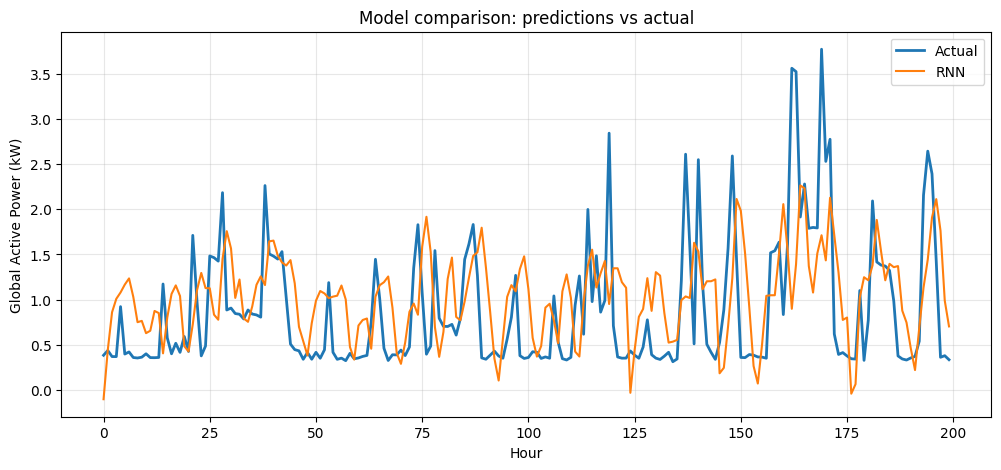

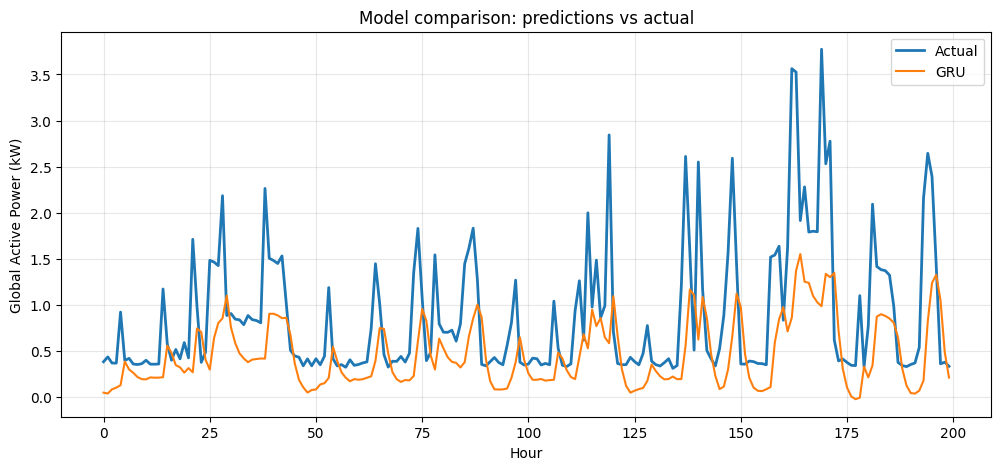

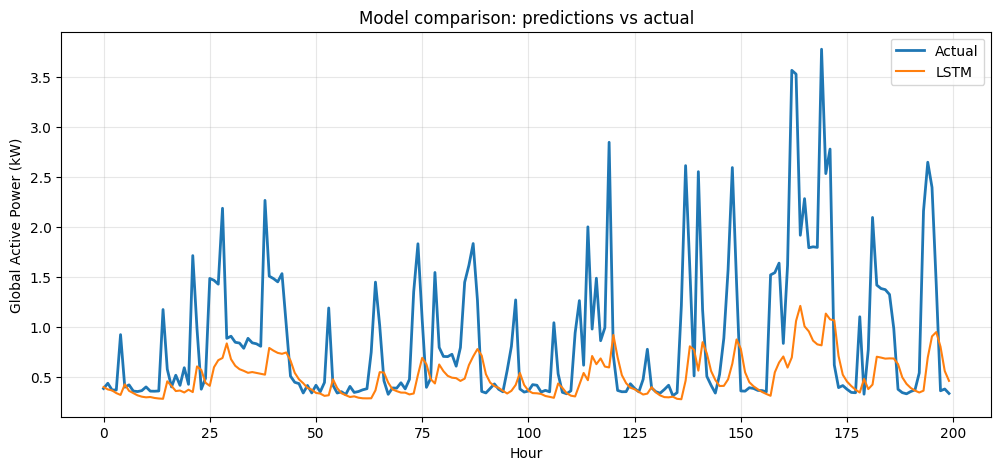

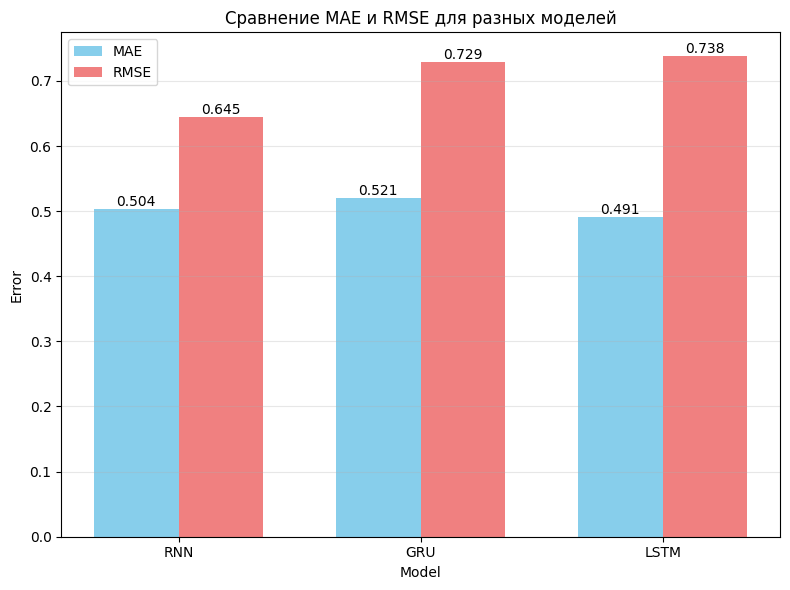

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(model, X_test, y_test, scaler, name="Model"):
    """
    model: FastRNN / FastGRU / FastLSTM
    """

    # --- prediction ---
    y_pred = model.predict(X_test)

    # many-to-one case
    if y_pred.ndim == 3:
        y_pred = y_pred[:, -1, :]

    # --- denormalization ---
    y_pred_real = scaler.inverse_transform(y_pred.reshape(-1, 1))
    y_test_real = scaler.inverse_transform(y_test.reshape(-1, 1))

    # --- metrics ---
    mae = mean_absolute_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))

    print(f"\n{name} результаты:")
    print(f"MAE : {mae:.4f} kW")
    print(f"RMSE: {rmse:.4f} kW")

    return mae, rmse, y_pred_real, y_test_real


rnn_mae, rnn_rmse, rnn_pred, y_real = evaluate_model(
    rnn, X_test, y_test, scaler, name="RNN"
)

gru_mae, gru_rmse, gru_pred, _ = evaluate_model(
    gru, X_test, y_test, scaler, name="GRU"
)

lstm_mae, lstm_rmse, lstm_pred, _ = evaluate_model(
    lstm, X_test, y_test, scaler, name="LSTM"
)

results = pd.DataFrame({
    "Model": ["RNN", "GRU", "LSTM"],
    "MAE": [rnn_mae, gru_mae, lstm_mae],
    "RMSE": [rnn_rmse, gru_rmse, lstm_rmse]
})

print(results)

model_dict = {'RNN': rnn_pred, 'GRU': gru_pred, 'LSTM': lstm_pred}

for model_name, model_pred in model_dict.items():
  plt.figure(figsize=(12,5))

  plt.plot(y_real[:200], label="Actual", linewidth=2)

  plt.plot(model_pred[:200], label=model_name)

  plt.title("Model comparison: predictions vs actual")
  plt.xlabel("Hour")
  plt.ylabel("Global Active Power (kW)")
  plt.legend()
  plt.grid(True, alpha=0.3)

  plt.show()

x = np.arange(len(results["Model"]))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, results["MAE"], width, label='MAE', color='skyblue')
bars2 = ax.bar(x + width/2, results["RMSE"], width, label='RMSE', color='lightcoral')

# Добавление значений на столбцы
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom')

ax.set_xlabel('Model')
ax.set_ylabel('Error')
ax.set_title('Сравнение MAE и RMSE для разных моделей')
ax.set_xticks(x)
ax.set_xticklabels(results["Model"])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
